<a href="https://colab.research.google.com/github/cristiangaymartin/tfm-estados-mercado/blob/main/notebooks/01_ingesta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install yfinance --quiet

In [2]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
ticker = "^GSPC"
sp500 = yf.download(ticker, start="1990-01-01", auto_adjust=True)
print(sp500.shape)   # (nº de filas, nº de columnas)
sp500.head()          # primeras filas para inspeccionar

[*********************100%***********************]  1 of 1 completed

(9232, 5)


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000


In [4]:
print("Rango de fechas:", sp500.index.min(), "→", sp500.index.max())
print("Valores ausentes por columna:")
print(sp500.isna().sum())

Rango de fechas: 1990-01-02 00:00:00 → 2026-08-28 00:00:00
Valores ausentes por columna:
Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
dtype: int64


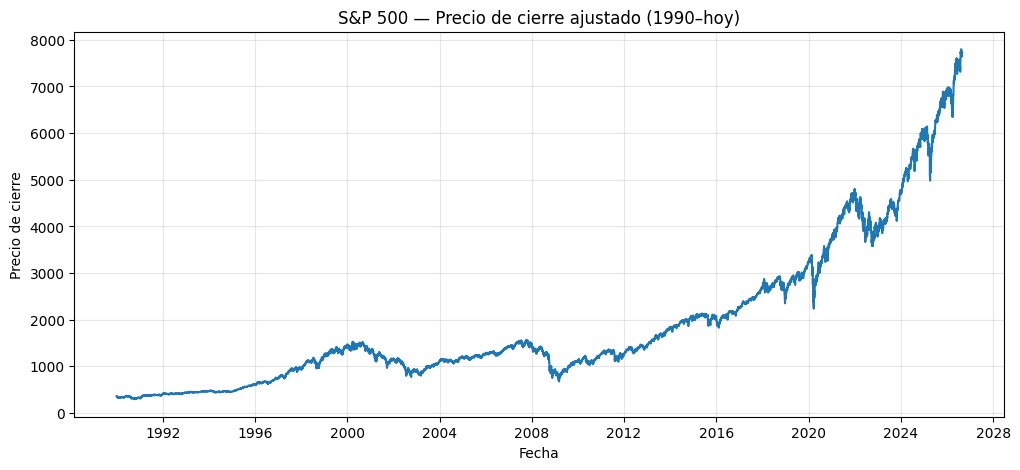

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(sp500.index, sp500["Close"])
plt.title("S&P 500 — Precio de cierre ajustado (1990–hoy)")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Antes: columnas con dos niveles (Price + Ticker)
print("Columnas antes:", sp500.columns.tolist())

# Eliminamos el segundo nivel (el del ticker), que es redundante con un solo activo
sp500.columns = sp500.columns.droplevel(1)

# Después: columnas simples
print("Columnas después:", sp500.columns.tolist())
sp500.head()

Columnas antes: [('Close', '^GSPC'), ('High', '^GSPC'), ('Low', '^GSPC'), ('Open', '^GSPC'), ('Volume', '^GSPC')]
Columnas después: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000


In [7]:
# Rendimiento simple: cambio porcentual diario
sp500["ret_simple"] = sp500["Close"].pct_change()

# Rendimiento logarítmico: log del cociente de precios consecutivos
sp500["ret_log"] = np.log(sp500["Close"] / sp500["Close"].shift(1))

# Miramos las primeras filas para entender qué ha pasado
sp500[["Close", "ret_simple", "ret_log"]].head()

Price,Close,ret_simple,ret_log
Date,,,
1990-01-02,359.690002,NaN,NaN
1990-01-03,358.760010,-0.002586,-0.002589
1990-01-04,355.670013,-0.008613,-0.008650
1990-01-05,352.200012,-0.009756,-0.009804
1990-01-08,353.790009,0.004514,0.004504


In [8]:
# Volatilidad = desviación típica de los log-rendimientos en una ventana de 21 días (~1 mes bursátil)
sp500["vol_21d"] = sp500["ret_log"].rolling(window=21).std()

# Visualizamos las tres piezas juntas
sp500[["ret_log", "vol_21d"]].tail(10)

Price,ret_log,vol_21d
Date,,
2026-08-17,-0.005241,0.008323
2026-08-18,-0.006906,0.008503
2026-08-19,0.002107,0.008342
2026-08-20,-0.008707,0.008606
2026-08-21,0.004337,0.008092
2026-08-24,-0.002807,0.008148
2026-08-25,0.003186,0.008150
2026-08-26,-0.000206,0.008159
2026-08-27,0.007177,0.007265


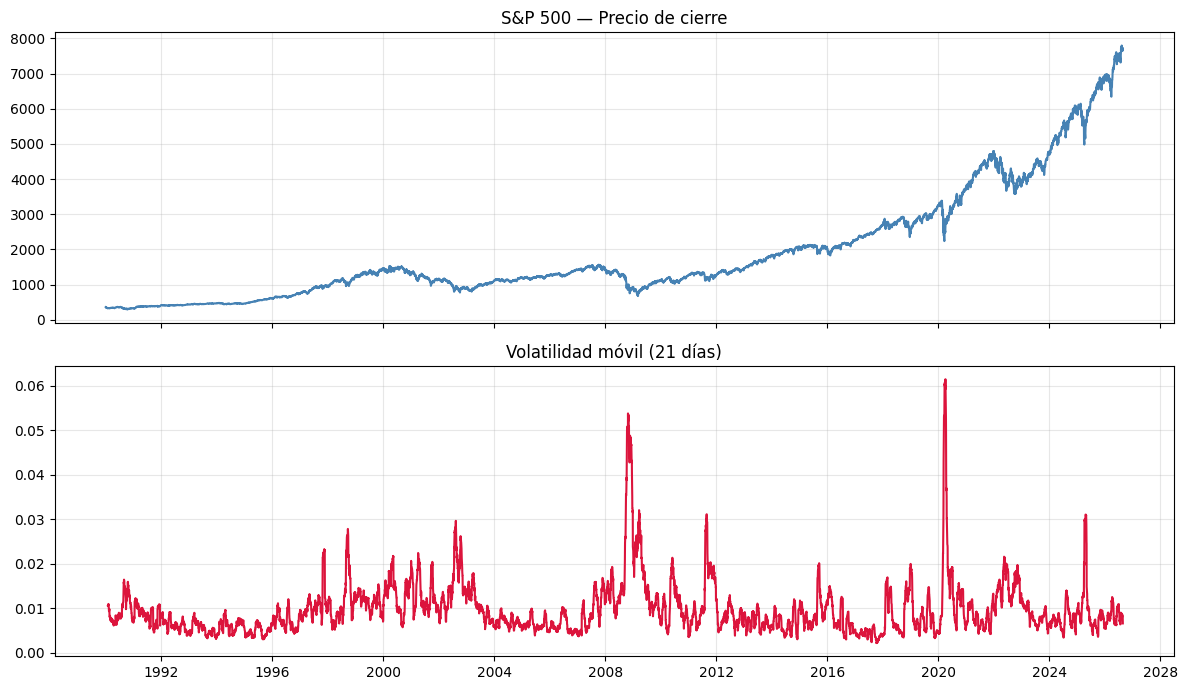

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(sp500.index, sp500["Close"], color="steelblue")
ax1.set_title("S&P 500 — Precio de cierre")
ax1.grid(True, alpha=0.3)

ax2.plot(sp500.index, sp500["vol_21d"], color="crimson")
ax2.set_title("Volatilidad móvil (21 días)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
sp500[["ret_log", "vol_21d"]].describe()

Price,ret_log,vol_21d
count,9231.000000,9211.000000
mean,0.000332,0.009699
std,0.011339,0.006012
min,-0.127652,0.002185
25%,-0.004414,0.006099
50%,0.000598,0.008249
75%,0.005704,0.011516
max,0.109572,0.061454


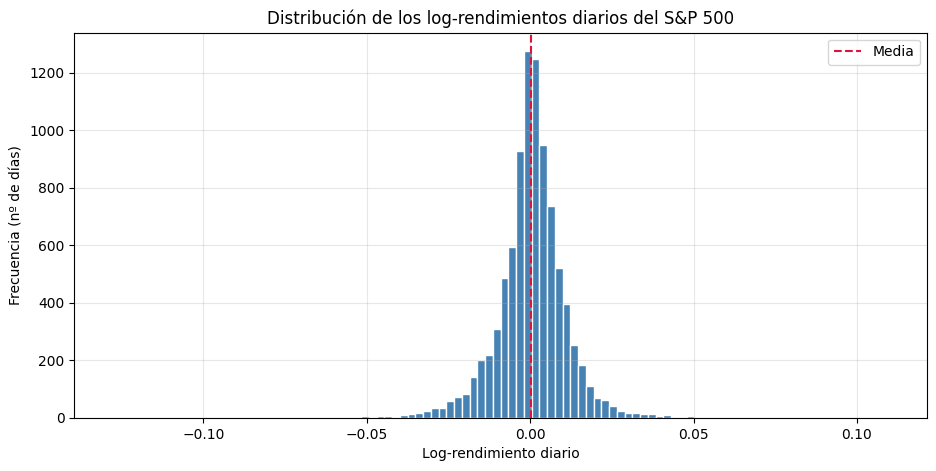

In [11]:
plt.figure(figsize=(11, 5))
plt.hist(sp500["ret_log"].dropna(), bins=100, color="steelblue", edgecolor="white")
plt.title("Distribución de los log-rendimientos diarios del S&P 500")
plt.xlabel("Log-rendimiento diario")
plt.ylabel("Frecuencia (nº de días)")
plt.axvline(sp500["ret_log"].mean(), color="crimson", linestyle="--", label="Media")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
print("5 peores días:")
print(sp500["ret_log"].nsmallest(5))
print("\n5 mejores días:")
print(sp500["ret_log"].nlargest(5))

5 peores días:
Date
2020-03-16   -0.127652
2020-03-12   -0.099945
2008-10-15   -0.094695
2008-12-01   -0.093537
2008-09-29   -0.092190
Name: ret_log, dtype: float64

5 mejores días:
Date
2008-10-13    0.109572
2008-10-28    0.102457
2025-04-09    0.090895
2020-03-24    0.089683
2020-03-13    0.088808
Name: ret_log, dtype: float64


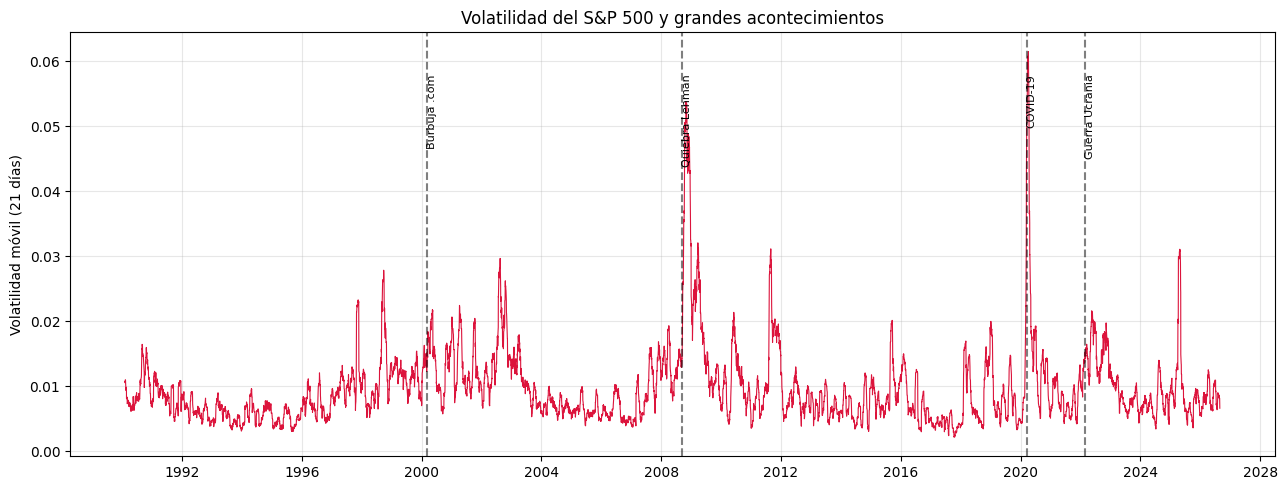

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sp500.index, sp500["vol_21d"], color="crimson", linewidth=0.8)
ax.set_title("Volatilidad del S&P 500 y grandes acontecimientos")
ax.set_ylabel("Volatilidad móvil (21 días)")
ax.grid(True, alpha=0.3)

# Marcamos algunos eventos históricos
eventos = {
    "2000-03-10": "Burbuja .com",
    "2008-09-15": "Quiebra Lehman",
    "2020-03-16": "COVID-19",
    "2022-02-24": "Guerra Ucrania",
}
for fecha, nombre in eventos.items():
    ax.axvline(pd.to_datetime(fecha), color="black", linestyle="--", alpha=0.5)
    ax.text(pd.to_datetime(fecha), ax.get_ylim()[1]*0.9, nombre,
            rotation=90, verticalalignment="top", fontsize=8)

plt.tight_layout()
plt.show()

** --- FUNCIÓN AUXILIAR PARA DESCARGAR MERCADOS --- **

In [14]:
def cargar_mercado(ticker, start="1990-01-01"):
    """
    Descarga un índice de Yahoo Finance y devuelve una tabla limpia
    con precio de cierre, log-rendimiento y volatilidad móvil de 21 días.

    Parámetros:
        ticker (str): símbolo del índice en Yahoo Finance (ej. '^GSPC').
        start (str): fecha de inicio en formato 'AAAA-MM-DD'.

    Devuelve:
        DataFrame con columnas: Close, ret_log, vol_21d.
    """
    # 1. Descarga
    df = yf.download(ticker, start=start, auto_adjust=True, progress=False)

    # 2. Aplanar el MultiIndex (quedarnos con el primer nivel de nombres)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    # 3. Nos quedamos solo con el cierre
    df = df[["Close"]].copy()

    # 4. Log-rendimiento
    df["ret_log"] = np.log(df["Close"] / df["Close"].shift(1))

    # 5. Volatilidad móvil de 21 días
    df["vol_21d"] = df["ret_log"].rolling(window=21).std()

    return df

In [15]:
# Probamos la función con el S&P 500
sp500_v2 = cargar_mercado("^GSPC", start="1990-01-01")

print(sp500_v2.shape)
print("Rango:", sp500_v2.index.min(), "→", sp500_v2.index.max())
sp500_v2.head()

(9232, 3)
Rango: 1990-01-02 00:00:00 → 2026-08-28 00:00:00


Price,Close,ret_log,vol_21d
Date,,,
1990-01-02,359.690002,NaN,NaN
1990-01-03,358.760010,-0.002589,NaN
1990-01-04,355.670013,-0.008650,NaN
1990-01-05,352.200012,-0.009804,NaN
1990-01-08,353.790009,0.004504,NaN


**FUNCIÓN AUXILIAR FINALIZADA**

In [16]:
tickers = {
    "SP500":     "^GSPC",
    "STOXX600":  "^STOXX",
    "IBEX35":    "^IBEX",
    "FTSE100":   "^FTSE",
    "Nikkei225": "^N225",
    "China":    "000001.SS",
    "Nifty50":   "^NSEI",
    "KOSPI":     "^KS11",
    "TAIEX":     "^TWII",
    "Jakarta":   "^JKSE",
    "Oro":       "GC=F",
    "BonoUSA":   "TLT",
}

In [17]:
mercados = {}   # aquí guardaremos cada tabla, etiquetada por nombre
fallos = {}     # aquí anotamos los que fallen, para revisarlos

for nombre, ticker in tickers.items():
    try:
        df = cargar_mercado(ticker, start="1990-01-01")
        if df.empty or df["Close"].dropna().empty:
            fallos[nombre] = "sin datos"
            print(f"⚠️  {nombre} ({ticker}): descarga vacía")
        else:
            mercados[nombre] = df
            print(f"✅ {nombre:10s} {df.shape[0]:5d} filas | desde {df.index.min().date()}")
    except Exception as e:
        fallos[nombre] = str(e)
        print(f"❌ {nombre} ({ticker}): {e}")

print(f"\nDescargados correctamente: {len(mercados)} | Con problemas: {len(fallos)}")

✅ SP500       9232 filas | desde 1990-01-02
✅ STOXX600    5618 filas | desde 2004-04-26
✅ IBEX35      8396 filas | desde 1993-07-12
✅ FTSE100     9260 filas | desde 1990-01-02
✅ Nikkei225   8995 filas | desde 1990-01-04
✅ China       7065 filas | desde 1997-07-02
✅ Nifty50     4649 filas | desde 2007-09-17
✅ KOSPI       7314 filas | desde 1996-12-11
✅ TAIEX       7146 filas | desde 1997-07-02
✅ Jakarta     8857 filas | desde 1990-04-06
✅ Oro         6523 filas | desde 2000-08-30
✅ BonoUSA     6060 filas | desde 2002-07-30

Descargados correctamente: 12 | Con problemas: 0


In [18]:
resumen = pd.DataFrame({
    nombre: {
        "inicio": df.index.min().date(),
        "fin": df.index.max().date(),
        "filas": df.shape[0]
    }
    for nombre, df in mercados.items()
}).T.sort_values("inicio")

resumen

,inicio,fin,filas
SP500,1990-01-02,2026-08-28,9232
FTSE100,1990-01-02,2026-08-28,9260
Nikkei225,1990-01-04,2026-08-28,8995
Jakarta,1990-04-06,2026-08-28,8857
IBEX35,1993-07-12,2026-08-28,8396
KOSPI,1996-12-11,2026-08-28,7314
China,1997-07-02,2026-08-28,7065
TAIEX,1997-07-02,2026-08-28,7146
Oro,2000-08-30,2026-08-28,6523
BonoUSA,2002-07-30,2026-08-28,6060


**Probamos otro índice que represente a China más allá de 2021**

In [19]:
candidatos_china = {
    "CSI300_SS":   "000300.SS",   # el que ya tienes (desde 2021)
    "Shanghai":    "000001.SS",   # índice compuesto de Shanghái (más antiguo)
    "FTSE_China":  "FXI",         # ETF de grandes empresas chinas (cotiza en USA)
    "MSCI_China":  "MCHI",        # ETF MSCI China (cotiza en USA)
}

for nombre, ticker in candidatos_china.items():
    try:
        df = cargar_mercado(ticker, start="1990-01-01")
        if df.empty or df["Close"].dropna().empty:
            print(f"⚠️  {nombre:12s} ({ticker}): sin datos")
        else:
            print(f"✅ {nombre:12s} ({ticker}): {df.shape[0]:5d} filas | desde {df.index.min().date()}")
    except Exception as e:
        print(f"❌ {nombre:12s} ({ticker}): {e}")

✅ CSI300_SS    (000300.SS):  1299 filas | desde 2021-03-11
✅ Shanghai     (000001.SS):  7065 filas | desde 1997-07-02
✅ FTSE_China   (FXI):  5507 filas | desde 2004-10-08
✅ MSCI_China   (MCHI):  3876 filas | desde 2011-03-31


**FASE 1. HORIZONTE COMÚN**

In [20]:
# Extraemos la columna de log-rendimiento de cada mercado y la etiquetamos con su nombre
retornos = pd.DataFrame({
    nombre: df["ret_log"]
    for nombre, df in mercados.items()
})

print("Forma de la tabla combinada (unión de todas las fechas):", retornos.shape)
retornos.tail()

Forma de la tabla combinada (unión de todas las fechas): (9545, 12)


,SP500,STOXX600,IBEX35,FTSE100,Nikkei225,China,Nifty50,KOSPI,TAIEX,Jakarta,Oro,BonoUSA
Date,,,,,,,,,,,,
2026-08-24,-0.002807,0.000046,0.006845,0.003479,-0.007424,-0.005957,-0.001360,-0.031743,-0.010268,-0.003688,0.003605,0.006196
2026-08-25,0.003186,0.003464,-0.002092,0.002935,0.004998,0.001914,0.004758,0.006813,0.009054,NaN,-0.000582,0.010962
2026-08-26,-0.000206,-0.000107,0.000533,-0.000744,0.006142,0.005916,-0.005224,0.009663,0.014575,-0.014873,-0.008640,-0.002039
2026-08-27,0.007177,-0.006971,-0.009297,-0.007900,-0.001967,0.011195,-0.004841,0.015183,0.003106,0.017957,0.002498,-0.002043
2026-08-28,-0.002491,0.005065,0.008030,0.002942,0.004128,-0.001111,0.003514,-0.018027,0.007718,-0.000557,-0.017463,-0.003012


In [21]:
print("Valores ausentes por mercado (sobre el total de fechas de la unión):")
print(retornos.isna().sum().sort_values(ascending=False))
print(f"\nTotal de fechas en la unión: {len(retornos)}")

Valores ausentes por mercado (sobre el total de fechas de la unión):
Nifty50      4897
STOXX600     3928
BonoUSA      3486
Oro          3023
China        2481
TAIEX        2400
KOSPI        2232
IBEX35       1150
Jakarta       689
Nikkei225     551
SP500         314
FTSE100       286
dtype: int64

Total de fechas en la unión: 9545


In [22]:
# La ventana común empieza cuando el último mercado se incorpora
inicio_comun = max(df.index.min() for df in mercados.values())
print("Inicio de la ventana común:", inicio_comun.date())

# Recortamos la tabla de retornos a partir de esa fecha
retornos_comun = retornos.loc[inicio_comun:].copy()
print("Forma tras fijar la ventana común:", retornos_comun.shape)

Inicio de la ventana común: 2007-09-17
Forma tras fijar la ventana común: (4938, 12)


In [23]:
# Nos quedamos solo con las fechas en que los DOCE mercados tienen dato real
retornos_intersec = retornos_comun.dropna()

print("Forma tras la intersección:", retornos_intersec.shape)
print("Rango final:", retornos_intersec.index.min().date(), "→", retornos_intersec.index.max().date())
print(f"\nFilas conservadas: {len(retornos_intersec)} de {len(retornos_comun)} "
      f"({100*len(retornos_intersec)/len(retornos_comun):.1f}%)")

Forma tras la intersección: (3520, 12)
Rango final: 2007-09-19 → 2026-08-28

Filas conservadas: 3520 de 4938 (71.3%)


In [24]:
print("Valores ausentes tras la intersección:", retornos_intersec.isna().sum().sum())

Valores ausentes tras la intersección: 0


In [25]:
# Para cada mercado, su rendimiento mínimo y máximo, y en qué fecha ocurrió
print("Rendimiento MÍNIMO y MÁXIMO por mercado:\n")
for col in retornos_intersec.columns:
    serie = retornos_intersec[col]
    fecha_min = serie.idxmin().date()
    fecha_max = serie.idxmax().date()
    print(f"{col:10s} | mín: {serie.min():+.4f} ({fecha_min}) | máx: {serie.max():+.4f} ({fecha_max})")

Rendimiento MÍNIMO y MÁXIMO por mercado:

SP500      | mín: -0.1277 (2020-03-16) | máx: +0.0909 (2025-04-09)
STOXX600   | mín: -0.1219 (2020-03-12) | máx: +0.0807 (2020-03-24)
IBEX35     | mín: -0.1515 (2020-03-12) | máx: +0.1348 (2010-05-10)
FTSE100    | mín: -0.1151 (2020-03-12) | máx: +0.0867 (2020-03-24)
Nikkei225  | mín: -0.1323 (2024-08-05) | máx: +0.1323 (2008-10-14)
China      | mín: -0.0887 (2015-08-24) | máx: +0.0903 (2008-09-19)
Nifty50    | mín: -0.1390 (2020-03-23) | máx: +0.1633 (2009-05-18)
KOSPI      | mín: -0.1285 (2026-03-04) | máx: +0.1648 (2026-07-31)
TAIEX      | mín: -0.0872 (2024-08-05) | máx: +0.0768 (2026-07-31)
Jakarta    | mín: -0.1131 (2008-10-06) | máx: +0.0970 (2020-03-26)
Oro        | mín: -0.1207 (2026-01-30) | máx: +0.0864 (2008-09-17)
BonoUSA    | mín: -0.0690 (2020-03-17) | máx: +0.0628 (2020-03-16)


In [26]:
# Miramos KOSPI y TAIEX alrededor del 31 de julio de 2026
ventana = retornos_intersec.loc["2026-07-28":"2026-07-31", ["KOSPI", "TAIEX", "Nikkei225", "SP500"]]
print("Contexto de los movimientos sospechosos (finales de julio 2026):\n")
print(ventana)

Contexto de los movimientos sospechosos (finales de julio 2026):

               KOSPI     TAIEX  Nikkei225     SP500
Date                                               
2026-07-28 -0.114699 -0.047660  -0.040325  0.002102
2026-07-29 -0.061699 -0.038322  -0.015036 -0.015277
2026-07-30 -0.012380 -0.002648   0.007027  0.016468
2026-07-31  0.164764  0.076771   0.039530  0.006979


In [27]:
# Matriz de correlaciones entre los rendimientos de los doce mercados
corr = retornos_intersec.corr()

# La mostramos redondeada a 2 decimales para que se lea bien
corr.round(2)

,SP500,STOXX600,IBEX35,FTSE100,Nikkei225,China,Nifty50,KOSPI,TAIEX,Jakarta,Oro,BonoUSA
SP500,1.00,0.60,0.53,0.56,0.15,0.09,0.29,0.20,0.17,0.19,0.04,-0.32
STOXX600,0.60,1.00,0.86,0.91,0.36,0.19,0.46,0.32,0.34,0.32,0.01,-0.28
IBEX35,0.53,0.86,1.00,0.79,0.30,0.13,0.40,0.26,0.26,0.26,0.01,-0.29
FTSE100,0.56,0.91,0.79,1.00,0.32,0.18,0.43,0.30,0.31,0.30,0.03,-0.28
Nikkei225,0.15,0.36,0.30,0.32,1.00,0.29,0.35,0.62,0.59,0.38,0.02,-0.09
China,0.09,0.19,0.13,0.18,0.29,1.00,0.25,0.31,0.33,0.25,0.05,-0.05
Nifty50,0.29,0.46,0.40,0.43,0.35,0.25,1.00,0.39,0.40,0.44,0.04,-0.12
KOSPI,0.20,0.32,0.26,0.30,0.62,0.31,0.39,1.00,0.68,0.45,0.07,-0.09
TAIEX,0.17,0.34,0.26,0.31,0.59,0.33,0.40,0.68,1.00,0.45,0.03,-0.09
Jakarta,0.19,0.32,0.26,0.30,0.38,0.25,0.44,0.45,0.45,1.00,0.05,-0.06


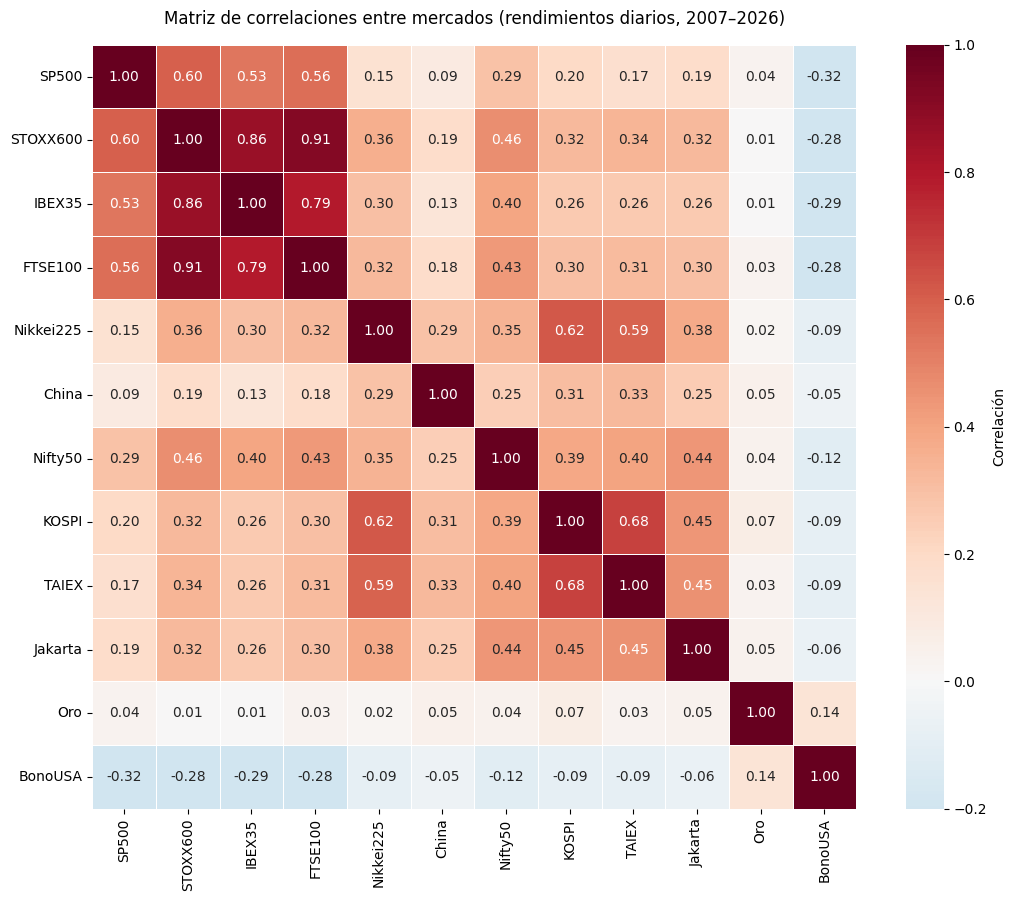

In [28]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,          # escribe el número dentro de cada casilla
    fmt=".2f",           # con 2 decimales
    cmap="RdBu_r",       # rojo = correlación alta, azul = baja/negativa
    center=0,            # el blanco queda en correlación 0
    vmin=-0.2, vmax=1,   # rango de la escala de color
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlación"}
)
plt.title("Matriz de correlaciones entre mercados (rendimientos diarios, 2007–2026)", pad=15)
plt.tight_layout()
plt.show()

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import os

# Carpeta del proyecto en tu Drive (ajústala si quieres otra ubicación)
RUTA_DATOS = "/content/drive/MyDrive/TFM/data"
os.makedirs(RUTA_DATOS, exist_ok=True)

print("Los datos se guardarán en:", RUTA_DATOS)

Los datos se guardarán en: /content/drive/MyDrive/TFM/data


In [31]:
# 1. Guardar cada mercado como un CSV independiente
for nombre, df in mercados.items():
    df.to_csv(f"{RUTA_DATOS}/mercado_{nombre}.csv")

# 2. Guardar la tabla de retornos de la ventana común (la que usaremos en comparativos)
retornos_intersec.to_csv(f"{RUTA_DATOS}/retornos_comun.csv")

print("Guardados", len(mercados), "mercados +  la tabla de retornos común.")
print("Archivos en la carpeta:")
print(os.listdir(RUTA_DATOS))

Guardados 12 mercados +  la tabla de retornos común.
Archivos en la carpeta:
['mercado_SP500.csv', 'mercado_STOXX600.csv', 'mercado_IBEX35.csv', 'mercado_FTSE100.csv', 'mercado_Nikkei225.csv', 'mercado_China.csv', 'mercado_Nifty50.csv', 'mercado_KOSPI.csv', 'mercado_TAIEX.csv', 'mercado_Jakarta.csv', 'mercado_Oro.csv', 'mercado_BonoUSA.csv', 'retornos_comun.csv']


## Congelación de datos para reproducibilidad

Para garantizar la reproducibilidad de los resultados, se congela el conjunto de
datos con fecha de corte **31 de diciembre de 2024**. Esto fija una versión
estable de las series sobre la que se realiza todo el análisis, y elimina el
tramo más reciente (2025-2026), que presentaba artefactos de borde en algunos
mercados (fechas finales inconsistentes entre índices).

Los datos congelados se guardan en `data_congelado/` y son los que utilizan los
notebooks de análisis. La aplicación desplegada, por su parte, opera sobre datos
actualizados en tiempo real para demostrar la aplicabilidad del método sobre
datos vivos; ambos comparten idéntica metodología y difieren solo en la ventana
temporal.

In [32]:
RUTA_DATOS = "/content/drive/MyDrive/TFM/data"
RUTA_CONGELADO = "/content/drive/MyDrive/TFM/data_congelado"
os.makedirs(RUTA_CONGELADO, exist_ok=True)

FECHA_CORTE = "2024-12-31"

# Todos los CSV de la carpeta (mercados + retornos_comun)
archivos = [f for f in os.listdir(RUTA_DATOS) if f.endswith(".csv")]
print(f"Archivos a congelar: {len(archivos)}\n")

for archivo in sorted(archivos):
    df = pd.read_csv(f"{RUTA_DATOS}/{archivo}", index_col=0, parse_dates=True)
    filas_antes = len(df)
    fecha_max_antes = df.index.max().date()

    df_congelado = df[df.index <= FECHA_CORTE].copy()
    filas_despues = len(df_congelado)
    fecha_max_despues = df_congelado.index.max().date()

    df_congelado.to_csv(f"{RUTA_CONGELADO}/{archivo}")
    print(f"{archivo:28s}: {filas_antes:5d} → {filas_despues:5d} filas "
          f"(hasta {fecha_max_antes} → {fecha_max_despues})")

print(f"\nDatos congelados guardados en: {RUTA_CONGELADO}")

Archivos a congelar: 13

mercado_BonoUSA.csv         :  6060 →  5645 filas (hasta 2026-08-28 → 2024-12-31)
mercado_China.csv           :  7065 →  6663 filas (hasta 2026-08-28 → 2024-12-31)
mercado_FTSE100.csv         :  9260 →  8840 filas (hasta 2026-08-28 → 2024-12-31)
mercado_IBEX35.csv          :  8396 →  7973 filas (hasta 2026-08-28 → 2024-12-31)
mercado_Jakarta.csv         :  8857 →  8468 filas (hasta 2026-08-28 → 2024-12-30)
mercado_KOSPI.csv           :  7314 →  6911 filas (hasta 2026-08-28 → 2024-12-30)
mercado_Nifty50.csv         :  4649 →  4238 filas (hasta 2026-08-28 → 2024-12-31)
mercado_Nikkei225.csv       :  8995 →  8592 filas (hasta 2026-08-28 → 2024-12-30)
mercado_Oro.csv             :  6523 →  6106 filas (hasta 2026-08-28 → 2024-12-31)
mercado_SP500.csv           :  9232 →  8817 filas (hasta 2026-08-28 → 2024-12-31)
mercado_STOXX600.csv        :  5618 →  5204 filas (hasta 2026-08-28 → 2024-12-30)
mercado_TAIEX.csv           :  7146 →  6745 filas (hasta 2026-08-28 → 202